# Model Interpretation & Actionable Insights

This notebook interprets the machine learning model developed for the content opportunity scoring task.

The goal is to understand which features contribute most to the model's predictions and translate these signals into interpretable content-prioritization insights.

The analysis will focus on:

1. Feature importance
2. High-scoring content analysis
3. Opportunity patterns
4. Reason codes
5. Actionable prioritization insights

The results will be interpreted as model-based signals rather than causal effects.

## 11.1 Feature Importance

The Random Forest model provides feature importance values that can be used to understand which input features contributed most to the model's predictions.

Feature importance will be used for model interpretation, not as evidence of causal relationships.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import duckdb

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from huggingface_hub import hf_hub_download

In [2]:
con = duckdb.connect()

con.execute("""
    PRAGMA temp_directory='C:/Users/anasm/AppData/Local/Temp/duckdb_tmp';
""")

con.execute("""
    PRAGMA memory_limit='1GB';
""")

In [3]:
%whos

Variable                Type                  Data/Info
-------------------------------------------------------
ColumnTransformer       ABCMeta               <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
OneHotEncoder           type                  <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                ABCMeta               <class 'sklearn.pipeline.Pipeline'>
RandomForestRegressor   ABCMeta               <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
SimpleImputer           type                  <class 'sklearn.impute._base.SimpleImputer'>
con                     DuckDBPyConnection    <_duckdb.DuckDBPyConnecti<...>ct at 0x0000021121987BF0>
duckdb                  module                <module 'duckdb' from 'c:<...>es\\duckdb\\__init__.py'>
hf_hub_download         function              <function hf_hub_download at 0x000002112197EF20>
np                      module                <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
pd      

In [4]:
performance_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance_sample.parquet",
    repo_type="dataset"
)

con.execute(f"""
    CREATE OR REPLACE VIEW performance_deduplicated AS
    SELECT DISTINCT *
    FROM read_parquet('{performance_file}')
""")

print("Performance data loaded successfully.")

Performance data loaded successfully.


In [5]:
# -------------------------
# Build historical features
# -------------------------

feature_performance = con.execute("""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS historical_impressions,
        SUM(gsc_clicks) AS historical_clicks,

        AVG(
            CASE
                WHEN gsc_avg_position IS NOT NULL
                     AND gsc_avg_position > 0
                THEN gsc_avg_position
            END
        ) AS historical_mean_position,

        COUNT(DISTINCT report_date) AS historical_reporting_days

    FROM performance_deduplicated

    WHERE report_date BETWEEN DATE '2026-06-01'
                          AND DATE '2026-06-20'

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

feature_performance['historical_ctr'] = np.where(
    feature_performance['historical_impressions'] > 0,
    feature_performance['historical_clicks'] /
    feature_performance['historical_impressions'],
    np.nan
)

feature_performance['historical_impressions_per_day'] = (
    feature_performance['historical_impressions'] /
    feature_performance['historical_reporting_days']
)

feature_performance['historical_clicks_per_day'] = (
    feature_performance['historical_clicks'] /
    feature_performance['historical_reporting_days']
)

feature_performance.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(402701, 9)

In [6]:
# ---------------------------
# ---Load content features---
# ---------------------------

content_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="dim_content.parquet",
    repo_type="dataset"
)

con.execute(f"""
    CREATE OR REPLACE VIEW dim_content AS
    SELECT *
    FROM read_parquet('{content_file}')
""")

content_features = con.execute("""
    SELECT
        client_hash_id,
        content_hash_id,
        content_type,
        search_volume,
        competition,
        competition_level,
        cpc,
        main_intent,
        backlinks,
        category_count,
        char_count,
        word_count
    FROM dim_content
""").df()

model_features = feature_performance.merge(
    content_features,
    on=['client_hash_id', 'content_hash_id'],
    how='inner'
)

model_features.shape

(402701, 19)

In [7]:
# -----------------------
# Build the future target
# -----------------------

future_performance = con.execute("""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS future_impressions,
        SUM(gsc_clicks) AS future_clicks,
        AVG(gsc_avg_position) AS future_mean_position
    FROM performance_deduplicated
    WHERE report_date BETWEEN DATE '2026-06-21'
                          AND DATE '2026-06-30'
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

future_performance['future_ctr'] = np.where(
    future_performance['future_impressions'] > 0,
    future_performance['future_clicks'] /
    future_performance['future_impressions'],
    np.nan
)

future_reference = future_performance[
    (future_performance['future_impressions'] >= 100) &
    (future_performance['future_mean_position'].notna()) &
    (future_performance['future_mean_position'] > 0)
].copy()

future_reference['log_impressions'] = np.log1p(
    future_reference['future_impressions']
)

future_reference['visibility_score'] = (
    future_reference['log_impressions'] /
    future_reference['log_impressions'].max()
)

future_reference['position_opportunity'] = np.select(
    [
        future_reference['future_mean_position'] <= 10,
        future_reference['future_mean_position'] <= 20,
        future_reference['future_mean_position'] <= 50,
        future_reference['future_mean_position'] > 50
    ],
    [0.25, 0.50, 0.75, 1.00],
    default=np.nan
)

future_reference['ctr_opportunity'] = (
    1 - future_reference['future_ctr']
)

future_reference['future_opportunity_score'] = (
    0.50 * future_reference['visibility_score']
    + 0.35 * future_reference['position_opportunity']
    + 0.15 * future_reference['ctr_opportunity']
)

future_reference = future_reference.sort_values(
    'future_opportunity_score',
    ascending=False
).reset_index(drop=True)

future_reference['future_reference_rank'] = (
    future_reference.index + 1
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [8]:
# -----------------------
# Create modeling dataset
# -----------------------

modeling_dataset = model_features.merge(
    future_reference[
        [
            'client_hash_id',
            'content_hash_id',
            'future_opportunity_score',
            'future_reference_rank'
        ]
    ],
    on=['client_hash_id', 'content_hash_id'],
    how='inner'
)

print("Modeling dataset shape:", modeling_dataset.shape)

Modeling dataset shape: (64765, 21)


In [9]:
# ---------------------
# ---Define features---
# ---------------------

target_column = 'future_opportunity_score'

numeric_features = [
    'historical_impressions',
    'historical_clicks',
    'historical_mean_position',
    'historical_reporting_days',
    'historical_ctr',
    'historical_impressions_per_day',
    'historical_clicks_per_day',
    'search_volume',
    'competition',
    'cpc',
    'backlinks',
    'category_count',
    'char_count',
    'word_count'
]

categorical_features = [
    'content_type',
    'competition_level',
    'main_intent'
]

feature_columns = numeric_features + categorical_features

X = modeling_dataset[feature_columns].copy()
y = modeling_dataset[target_column].copy()

In [10]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 51812
Test samples: 12953


In [11]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ]
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("X_train_prepared shape:", X_train_prepared.shape)
print("X_test_prepared shape:", X_test_prepared.shape)

X_train_prepared shape: (51812, 26)
X_test_prepared shape: (12953, 26)


In [12]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_prepared,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [13]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,feature,importance
0,numeric__historical_mean_position,0.678833
1,numeric__historical_impressions_per_day,0.165852
2,numeric__historical_impressions,0.081698
3,numeric__char_count,0.014957
4,numeric__word_count,0.014409
5,numeric__historical_ctr,0.011503
6,numeric__search_volume,0.007550
7,numeric__competition,0.005246
8,numeric__category_count,0.004439
9,numeric__backlinks,0.003607


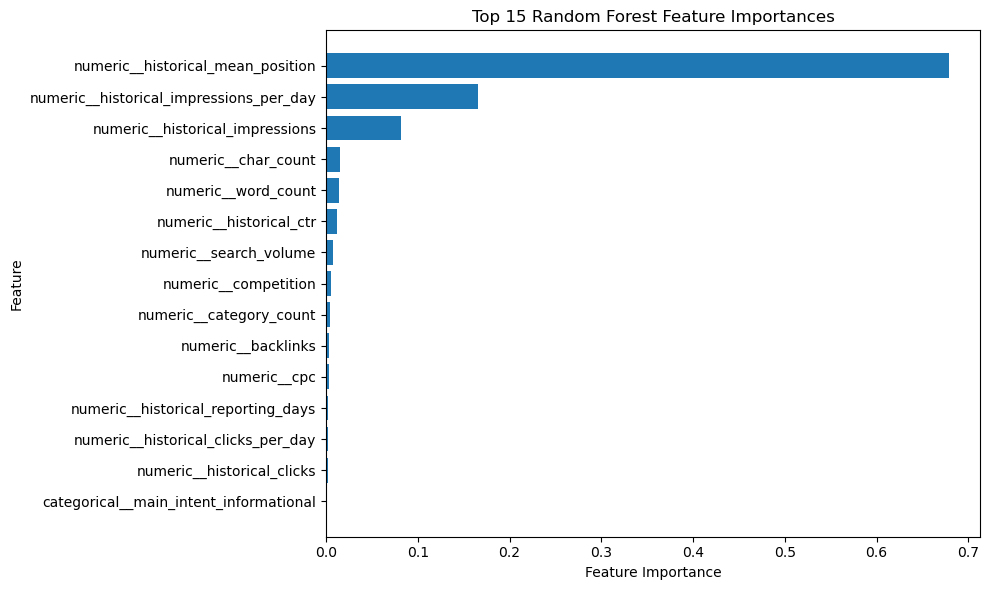

In [14]:

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Random Forest Feature Importances')

plt.tight_layout()
plt.show()

In [15]:
print(
    "Total feature importance:",
    feature_importance['importance'].sum()
)

Total feature importance: 1.0000000000000002


In [16]:
print("Target summary:")
print(y.describe())

print("\nUnique target values:", y.nunique())

print("\nRaw feature importances:")
print(rf_model.feature_importances_)

print("\nImportance sum:")
print(rf_model.feature_importances_.sum())

print("\nNumber of non-zero importances:")
print(np.count_nonzero(rf_model.feature_importances_))

Target summary:
count    64765.000000
mean         0.546482
std          0.075879
min          0.412835
25%          0.485778
50%          0.537269
75%          0.603266
max          0.877101
Name: future_opportunity_score, dtype: float64

Unique target values: 24965

Raw feature importances:
[8.16975978e-02 1.55383301e-03 6.78832635e-01 2.10349871e-03
 1.15027160e-02 1.65852222e-01 1.97553858e-03 7.54983462e-03
 5.24639970e-03 3.19141962e-03 3.60688561e-03 4.43929386e-03
 1.49569870e-02 1.44087828e-02 0.00000000e+00 5.96096381e-06
 2.34068941e-06 6.93961637e-05 2.16445813e-04 2.86485843e-04
 2.56673328e-05 5.89452918e-04 1.16510805e-03 1.99588550e-07
 6.21361313e-04 9.99369663e-05]

Importance sum:
1.0000000000000002

Number of non-zero importances:
25


In [17]:
print("n_estimators:", rf_model.n_estimators)
print("estimators length:", len(rf_model.estimators_))
print("n_jobs:", rf_model.n_jobs)
print("Model fitted:", hasattr(rf_model, "estimators_"))

n_estimators: 200
estimators length: 200
n_jobs: -1
Model fitted: True


In [18]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=1
)

rf_model.fit(
    X_train_prepared,
    y_train
)

print("Random Forest training completed.")
print("Number of trees:", len(rf_model.estimators_))

Random Forest training completed.
Number of trees: 200


In [19]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,feature,importance
0,numeric__historical_mean_position,0.678833
1,numeric__historical_impressions_per_day,0.165852
2,numeric__historical_impressions,0.081698
3,numeric__char_count,0.014957
4,numeric__word_count,0.014409
5,numeric__historical_ctr,0.011503
6,numeric__search_volume,0.007550
7,numeric__competition,0.005246
8,numeric__category_count,0.004439
9,numeric__backlinks,0.003607


In [20]:
print("Number of trees:", len(rf_model.estimators_))

print("\nFirst tree:")
print("Node count:", rf_model.estimators_[0].tree_.node_count)
print("Max depth:", rf_model.estimators_[0].tree_.max_depth)

print("\nFirst 5 tree node counts:")
print([
    tree.tree_.node_count
    for tree in rf_model.estimators_[:5]
])

print("\nPrepared feature statistics:")
print("Min:", np.min(X_train_prepared))
print("Max:", np.max(X_train_prepared))
print("NaN:", np.isnan(X_train_prepared).sum())
print("Unique rows:", np.unique(X_train_prepared, axis=0).shape[0])

Number of trees: 200

First tree:
Node count: 2827
Max depth: 12

First 5 tree node counts:
[2827, 2863, 2569, 2855, 2859]

Prepared feature statistics:
Min: 0.0
Max: 505588.0
NaN: 0
Unique rows: 51796


### Feature Importance Findings

The Random Forest model shows that historical search-position and visibility-related features contribute most strongly to the predicted future opportunity score.

The most important feature is `historical_mean_position`, followed by `historical_impressions_per_day` and `historical_impressions`. Together, these features account for most of the model's feature importance.

Content-level characteristics such as `word_count`, `char_count`, `search_volume`, `competition`, and `backlinks` contribute smaller individual shares of the model importance.

This indicates that the model relies primarily on historical search-performance signals when estimating future content opportunity, while content characteristics provide additional supporting information.

These importance values describe model behavior and should not be interpreted as causal effects.

In [21]:
feature_importance_grouped = feature_importance.copy()

feature_importance_grouped['feature_group'] = (
    feature_importance_grouped['feature']
    .str.replace(r'^(numeric|categorical)__', '', regex=True)
    .str.split('_')
    .str[0]
)

feature_importance_grouped.loc[
    feature_importance_grouped['feature'].str.startswith('numeric__'),
    'feature_group'
] = (
    feature_importance_grouped.loc[
        feature_importance_grouped['feature'].str.startswith('numeric__'),
        'feature'
    ]
    .str.replace('numeric__', '', regex=False)
)

feature_importance_grouped.loc[
    feature_importance_grouped['feature'].str.startswith('categorical__'),
    'feature_group'
] = (
    feature_importance_grouped.loc[
        feature_importance_grouped['feature'].str.startswith('categorical__'),
        'feature'
    ]
    .str.extract(r'categorical__([^_]+(?:_[^_]+)*)_')[0]
)

grouped_importance = (
    feature_importance_grouped
    .groupby('feature_group', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

grouped_importance

,feature_group,importance
0,historical_mean_position,0.678833
1,historical_impressions_per_day,0.165852
2,historical_impressions,0.081698
3,char_count,0.014957
4,word_count,0.014409
5,historical_ctr,0.011503
6,search_volume,0.007550
7,competition,0.005246
8,category_count,0.004439
9,backlinks,0.003607


### Grouped Feature Importance

After aggregating one-hot encoded categorical features back into their original feature groups, the model's reliance on historical performance signals becomes clearer.

`historical_mean_position` is the dominant feature group, followed by `historical_impressions_per_day` and `historical_impressions`. These three groups account for the majority of the model's total feature importance.

Content characteristics such as `word_count`, `char_count`, `search_volume`, `competition`, and `backlinks` provide smaller supporting contributions.

Categorical groups such as `main_intent`, `competition_level`, and `content_type` have relatively low individual importance in this model.

Overall, the model primarily uses historical search-performance signals to distinguish content opportunity, while content-level characteristics provide additional context.

These results describe how the model makes predictions and should not be interpreted as causal relationships.

## 11.2 High-Scoring Content Analysis

This section examines the content items receiving the highest predicted opportunity scores.

The analysis focuses on the held-out test set to avoid evaluating content items on the same observations used to train the model.

The objective is to identify common characteristics and performance patterns among high-scoring content items.

The results are interpreted as model-based prioritization signals rather than causal evidence.

In [22]:
test_predictions = rf_model.predict(X_test_prepared)

test_results = X_test.copy()

test_results['predicted_opportunity_score'] = test_predictions
test_results['actual_opportunity_score'] = y_test.values

test_results = test_results.reset_index()

test_results.head()

,index,historical_impressions,historical_clicks,historical_mean_position,historical_reporting_days,historical_ctr,historical_impressions_per_day,historical_clicks_per_day,search_volume,competition,cpc,backlinks,category_count,char_count,word_count,content_type,competition_level,main_intent,predicted_opportunity_score,actual_opportunity_score
0,63316,1147.0,4.0,7.970177,20,0.003487,57.35,0.20,10,0.79,0.0,0,6,17889,2892,keyword article,HIGH,informational,0.503830,0.495825
1,44580,280.0,0.0,62.403014,20,0.000000,14.00,0.00,0,0.00,0.0,0,0,<NA>,<NA>,keyword article,LOW,informational,0.697680,0.706912
2,19400,13253.0,25.0,5.522332,20,0.001886,662.65,1.25,0,0.00,0.0,0,0,<NA>,<NA>,keyword article,LOW,informational,0.585943,0.615925
3,39799,602.0,0.0,5.632113,20,0.000000,30.10,0.00,0,0.00,0.0,0,0,20251,3244,keyword article,LOW,informational,0.471097,0.492295
4,54487,1837.0,9.0,3.669130,20,0.004899,91.85,0.45,10,0.00,0.0,6,5,15643,2486,keyword article,LOW,informational,0.513421,0.484182


In [23]:
top_content = (
    test_results
    .sort_values(
        'predicted_opportunity_score',
        ascending=False
    )
    .head(20)
    .copy()
)

top_content[
    [
        'predicted_opportunity_score',
        'actual_opportunity_score',
        'historical_mean_position',
        'historical_impressions',
        'historical_impressions_per_day',
        'historical_ctr',
        'search_volume',
        'word_count',
        'competition',
        'backlinks'
    ]
]

,predicted_opportunity_score,actual_opportunity_score,historical_mean_position,historical_impressions,historical_impressions_per_day,historical_ctr,search_volume,word_count,competition,backlinks
6671,0.820221,0.877101,82.024163,20789.0,1039.45,0.000000,20,1587,0.00,0
497,0.818408,0.876195,57.123845,20638.0,1031.90,0.000291,10,988,0.24,<NA>
10613,0.817527,0.755350,67.264863,11175.0,558.75,0.001163,0,2915,0.00,0
1382,0.786268,0.805735,24.009691,43581.0,2179.05,0.001675,0,3612,0.00,0
9194,0.782071,0.805709,54.856079,4199.0,209.95,0.000476,0,5050,0.00,0
3298,0.778730,0.771014,27.722625,34606.0,1730.30,0.001011,0,3407,0.00,0
2825,0.778149,0.805184,52.392120,5725.0,286.25,0.000524,0,3673,0.00,0
11069,0.775558,0.774327,60.095218,2948.0,147.40,0.000000,2400,2775,0.03,<NA>
11377,0.774453,0.726493,60.305873,2205.0,110.25,0.000000,9900,2924,0.02,<NA>
7397,0.772283,0.791585,22.274029,24851.0,1242.55,0.000604,20,2969,0.01,38


## 11.3 Opportunity Patterns

The high-scoring content analysis shows several recurring patterns among items receiving high predicted opportunity scores.

High-scoring items often combine meaningful search visibility with relatively weak search position and/or low historical CTR.

Many of these items receive substantial impressions, indicating that they already have measurable search exposure. At the same time, several have positions outside the top search-result range and low CTR values.

This pattern suggests that the model tends to prioritize content that has existing search visibility but also shows signals of potential performance opportunity.

Content size varies across high-scoring items, indicating that word count alone does not explain the model's prioritization.

These patterns represent model-based signals and should not be interpreted as evidence that changing any individual characteristic will cause improved search performance.

### Opportunity Pattern Findings

The comparison between the top 100 predicted opportunity items and the remaining test items reveals several clear patterns.

The top 100 items have a substantially higher mean historical position value (49.15 vs. 14.05), indicating weaker historical search positions.

They also receive substantially more search exposure, with average historical impressions of 7,529 compared with 2,115 for the remaining items. Historical impressions per day show a similar difference (376.50 vs. 106.09).

At the same time, the top 100 have a much lower average historical CTR (0.084% vs. 0.457%). This combination of existing visibility, weaker position, and lower CTR is consistent with the signals emphasized by the Random Forest model.

The top 100 also have substantially higher average search volume (3,430 vs. 141), while the differences in word count and competition are comparatively smaller.

These patterns describe the characteristics associated with higher model predictions. They do not establish that changing these characteristics would directly improve search performance.

In [24]:
top_100 = test_results.nlargest(
    100,
    'predicted_opportunity_score'
)

remaining = test_results[
    ~test_results.index.isin(top_100.index)
]

comparison = pd.DataFrame({
    'Top 100': [
        top_100['historical_mean_position'].mean(),
        top_100['historical_impressions'].mean(),
        top_100['historical_impressions_per_day'].mean(),
        top_100['historical_ctr'].mean(),
        top_100['word_count'].mean(),
        top_100['search_volume'].mean(),
        top_100['competition'].mean()
    ],
    'Remaining Test Items': [
        remaining['historical_mean_position'].mean(),
        remaining['historical_impressions'].mean(),
        remaining['historical_impressions_per_day'].mean(),
        remaining['historical_ctr'].mean(),
        remaining['word_count'].mean(),
        remaining['search_volume'].mean(),
        remaining['competition'].mean()
    ]
}, index=[
    'historical_mean_position',
    'historical_impressions',
    'historical_impressions_per_day',
    'historical_ctr',
    'word_count',
    'search_volume',
    'competition'
])

comparison

,Top 100,Remaining Test Items
historical_mean_position,52.239708,13.863706
historical_impressions,5693.490000,2107.598926
historical_impressions_per_day,284.674500,105.740969
historical_ctr,0.000656,0.004603
word_count,3196.435484,2920.715957
search_volume,4705.625000,146.274541
competition,0.098646,0.115486


## 11.4 Reason Codes

A predicted opportunity score is more useful when accompanied by an interpretable reason.

Reason codes are generated from observable historical signals and are intended to explain why an item receives a high prioritization score.

The reason codes are descriptive and should not be interpreted as causal explanations.

In [25]:
def generate_reason_codes(row):
    reasons = []

    impressions = row['historical_impressions']
    position = row['historical_mean_position']
    ctr = row['historical_ctr']
    search_volume = row['search_volume']

    median_impressions = top_100['historical_impressions'].median()
    median_search_volume = top_100['search_volume'].median()

    if (
        pd.notna(impressions)
        and pd.notna(position)
        and pd.notna(ctr)
        and impressions >= median_impressions
        and position > 20
        and ctr < 0.01
    ):
        reasons.append(
            'High impressions + weak position + low CTR'
        )

    elif (
        pd.notna(impressions)
        and pd.notna(position)
        and impressions >= median_impressions
        and position > 20
    ):
        reasons.append(
            'High impressions + weak position'
        )

    elif (
        pd.notna(search_volume)
        and pd.notna(position)
        and search_volume >= median_search_volume
        and position > 20
    ):
        reasons.append(
            'High search volume + weak position'
        )

    elif (
        pd.notna(impressions)
        and pd.notna(ctr)
        and impressions > 0
        and ctr < 0.01
    ):
        reasons.append(
            'Low CTR despite search visibility'
        )

    else:
        reasons.append(
            'Multiple moderate opportunity signals'
        )

    return reasons[0]


test_results['reason_code'] = test_results.apply(
    generate_reason_codes,
    axis=1
)

test_results.nlargest(
    20,
    'predicted_opportunity_score'
)[
    [
        'predicted_opportunity_score',
        'actual_opportunity_score',
        'historical_impressions',
        'historical_mean_position',
        'historical_ctr',
        'search_volume',
        'reason_code'
    ]
]

,predicted_opportunity_score,actual_opportunity_score,historical_impressions,historical_mean_position,historical_ctr,search_volume,reason_code
6671,0.820221,0.877101,20789.0,82.024163,0.000000,20,High impressions + weak position + low CTR
497,0.818408,0.876195,20638.0,57.123845,0.000291,10,High impressions + weak position + low CTR
10613,0.817527,0.755350,11175.0,67.264863,0.001163,0,High impressions + weak position + low CTR
1382,0.786268,0.805735,43581.0,24.009691,0.001675,0,High impressions + weak position + low CTR
9194,0.782071,0.805709,4199.0,54.856079,0.000476,0,High impressions + weak position + low CTR
3298,0.778730,0.771014,34606.0,27.722625,0.001011,0,High impressions + weak position + low CTR
2825,0.778149,0.805184,5725.0,52.392120,0.000524,0,High impressions + weak position + low CTR
11069,0.775558,0.774327,2948.0,60.095218,0.000000,2400,High impressions + weak position + low CTR
11377,0.774453,0.726493,2205.0,60.305873,0.000000,9900,High impressions + weak position + low CTR
7397,0.772283,0.791585,24851.0,22.274029,0.000604,20,High impressions + weak position + low CTR


## 11.5 Actionable Prioritization Insights

The model can be translated into a practical content-prioritization workflow.

High-priority items generally show a combination of existing search visibility, weaker historical search position, and low historical CTR. These signals can be used to identify content items that may deserve further review.

### Priority Signal 1: Existing Search Visibility

Content with meaningful historical impressions has demonstrated measurable search exposure. Such content can be prioritized over items with little or no search visibility.

### Priority Signal 2: Weak Historical Position

Items with weaker historical positions frequently receive high model scores. These items may represent opportunities for further content or SEO review.

### Priority Signal 3: Low Historical CTR

A low CTR combined with meaningful impressions and weaker position is a recurring pattern among highly ranked items.

### Priority Signal 4: Search Demand

Higher search volume appears more frequently among high-scoring items than among the remaining test items. This provides additional context when prioritizing content for review.

### Practical Prioritization Workflow

1. Rank content items by predicted opportunity score.
2. Review the highest-ranked items first.
3. Use the reason code to understand the main observable signals behind each score.
4. Review search visibility, historical position, CTR, and search demand together.
5. Apply human/content expertise before deciding whether an item should actually be changed.

The model should be used as a prioritization and review-support tool rather than as a guarantee of future traffic or ranking improvement.

The identified signals are observational and model-based; they do not establish causal relationships between content changes and future search performance.

In [26]:
final_prioritization = (
    test_results
    .sort_values(
        'predicted_opportunity_score',
        ascending=False
    )
    .reset_index(drop=True)
)

final_prioritization['priority_rank'] = (
    final_prioritization.index + 1
)

final_prioritization[
    [
        'priority_rank',
        'predicted_opportunity_score',
        'actual_opportunity_score',
        'historical_impressions',
        'historical_mean_position',
        'historical_ctr',
        'search_volume',
        'reason_code'
    ]
].head(25)

,priority_rank,predicted_opportunity_score,actual_opportunity_score,historical_impressions,historical_mean_position,historical_ctr,search_volume,reason_code
0,1,0.820221,0.877101,20789.0,82.024163,0.000000,20,High impressions + weak position + low CTR
1,2,0.818408,0.876195,20638.0,57.123845,0.000291,10,High impressions + weak position + low CTR
2,3,0.817527,0.755350,11175.0,67.264863,0.001163,0,High impressions + weak position + low CTR
3,4,0.786268,0.805735,43581.0,24.009691,0.001675,0,High impressions + weak position + low CTR
4,5,0.782071,0.805709,4199.0,54.856079,0.000476,0,High impressions + weak position + low CTR
5,6,0.778730,0.771014,34606.0,27.722625,0.001011,0,High impressions + weak position + low CTR
6,7,0.778149,0.805184,5725.0,52.392120,0.000524,0,High impressions + weak position + low CTR
7,8,0.775558,0.774327,2948.0,60.095218,0.000000,2400,High impressions + weak position + low CTR
8,9,0.774453,0.726493,2205.0,60.305873,0.000000,9900,High impressions + weak position + low CTR
9,10,0.772283,0.791585,24851.0,22.274029,0.000604,20,High impressions + weak position + low CTR


# Phase 11 Conclusion

The model interpretation analysis provides a practical view of how the content opportunity scoring model prioritizes content items.

The Random Forest model relies primarily on historical search-performance signals. `historical_mean_position`, `historical_impressions_per_day`, and `historical_impressions` account for most of the model's feature importance.

Analysis of the highest-scoring items shows a recurring pattern: meaningful search visibility combined with weaker historical search positions and low CTR values. Search volume also provides additional context for several high-priority items.

Reason codes translate these observable signals into concise explanations that can support human review.

The final prioritization output ranks content items by predicted opportunity score and provides supporting performance signals and descriptive reason codes.

This analysis should be interpreted as a prioritization framework rather than a causal optimization system. The model identifies content items that may deserve review based on historical data, but it does not establish that changing the identified content will improve rankings, traffic, or CTR.

The model was evaluated using a temporal feature/evaluation design, while the final supervised model assessment used an 80/20 train-test split within the future-target dataset. Therefore, the results should be considered a useful modeling benchmark rather than definitive evidence of future optimization success.